# **Week2 복습과제**

**1. [ANN]**

**2. [CNN]**

- 데이터는 Week 1 과 같이 MNIST (0-9 숫자 분류) 데이터셋입니다.
- 이때, 우리의 복습과제에서는 0-4 숫자 분류를 위한 데이터 샘플만 사용할 예정입니다
- 아래 코드를 실행시켜 주세요

In [1]:
import torch
import torchvision.transforms as transforms
from torchvision.datasets import MNIST
from torch.utils.data import DataLoader, Subset
import random

# Tensor 변환을 위함
transform = transforms.Compose([
    transforms.ToTensor()
])

# MNIST 데이터셋 불러오기
train_dataset = MNIST(root='./data', train=True, transform=transform, download=True)
test_dataset = MNIST(root='./data', train=False, transform=transform, download=True)

# 무작위로 샘플 인덱스 선택
train_indices = [i for i, label in enumerate(train_dataset.targets) if label in [0, 1, 2, 3, 4]]
test_indices = [i for i, label in enumerate(test_dataset.targets) if label in [0, 1, 2, 3, 4]]

# Subset을 사용하여 샘플링된 데이터셋 생성
train_subset = Subset(train_dataset, train_indices)
test_subset = Subset(test_dataset, test_indices)


# DataLoader 생성
batch_size = 64  # 배치 크기는 64로 설정 (batch_size를 다르게 실행해보셔도 좋습니다)
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=batch_size, shuffle=False)

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 481kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.63MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.0MB/s]


In [2]:
# 데이터셋 크기 확인을 위해 해당 셀을 실행시켜 주세요
print(f"Train dataset size: {len(train_subset)}")
print(f"Test dataset size: {len(test_subset)}")

Train dataset size: 30596
Test dataset size: 5139


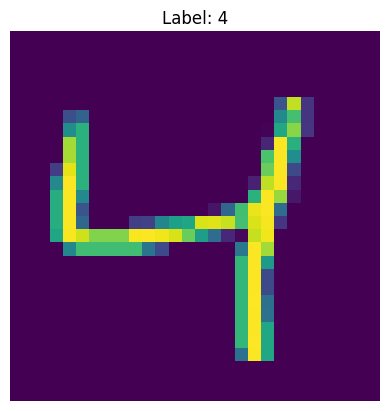

In [3]:
# 데이터셋 중 하나의 이미지를 시각화해보기
import matplotlib.pyplot as plt
import numpy as np

# 데이터셋에서 하나의 샘플 가져오기
image, label = train_subset[1]

# 텐서를 NumPy 배열로 변환
image = image.numpy().squeeze()

# 이미지 출력
plt.imshow(image)  # 이미지 표시
plt.title(f"Label: {label}")  # 레이블 표시
plt.axis("off")  # 축 없애기
plt.show()

<a id="1"></a> <br>
## **1. ANN**

**인공 신경망 (ANN)**

>  로지스틱 회귀는 분류 문제에서 성능이 좋지만, 데이터의 비선형성이 증가하면 모델의 정확도가 감소합니다.

>  따라서, hidden lyaer 에 더 많은 비선형 함수를 추가시켜 모델의 복잡도를 증가시켜 봅시다. 😀

↪ **3개의 hidden layer를 쌓고 다양한 활성화 함수 ReLU, Tanh, ELU 사용해봅시다**


In [4]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn

#### **ANN 모델 생성**

In [11]:
# ANN Model
class ANNModel(nn.Module):

    def __init__(self, input_dim, hidden_dim, output_dim):
        super(ANNModel, self).__init__()

        # Linear function 1: ____ --> ____  (입력 차원에서 숨겨진 계층으로)
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        # Non-linearity 1 (ReLU 활성화 함수)
        self.relu1 = nn.ReLU()

        # Linear function 2: ____ --> ____  (숨겨진 계층을 한 번 더 통과)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 2 (Tanh 활성화 함수 사용)
        self.tanh2 = nn.Tanh()

        # Linear function 3: ____ --> ____  (추가 숨겨진 계층)
        self.fc3 = nn.Linear(hidden_dim, hidden_dim)
        # Non-linearity 3 (ELU 활성화 함수)
        self.elu3 = nn.ELU()

        # Linear function 4: ____ --> ____  (마지막 출력층)
        self.fc4 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        # Linear function 1
        out = self.fc1(x)
        # Non-linearity 1
        out = self.relu1 (out)

        # Linear function 2
        out = self.fc2(out)
        # Non-linearity 2
        out = self.tanh2 (out)

        # Linear function 3
        out = self.fc3(out)
        # Non-linearity 3
        out = self.elu3 (out)

        # Linear function 4
        out = self.fc4(out)  # 마지막 출력층
        return out

In [12]:
# ANN 객체 생성
input_dim = 28 * 28  # 이미지 크기 (28x28)
hidden_dim = 150  # 하이퍼파라미터 (150으로 설정)
output_dim = 5  # 출력 클래스 개수 (0~4)


model = ANNModel(input_dim,hidden_dim,output_dim)
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss() # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
learning_rate = 0.02
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

#### **ANN 모델 학습**

In [13]:
# ANN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트

# 전체 학습
for epoch in range(10):

    # 배치 단위 학습
    for i, (images, labels) in enumerate(train_loader):

        # 데이터를 모델 입력 형태로 변환 (2D 텐서로 펼치기)
        train = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
        labels = labels  # 텐서 형태 유지

        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        # 모델을 이용해 예측값(outputs) 계산
        outputs = model(train)

        # 손실 계산
        # cross entropy loss를 사용해 예측값과 실제값 비교
        loss = loss_ftn(outputs, labels)

        # Backward propagation - 손실에 대한 기울기 계산
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            # 정확도 계산을 위한 변수 초기화
            correct = 0
            total = 0


            # 모델이 테스트 데이터셋에서 얼마나 잘 예측하는지 확인
            for images, labels in test_loader:

                test = images.view(-1, 28 * 28)  # 28x28 이미지를 펼쳐서 1D 벡터로 변환
                # Forward
                # 예측값 계산
                outputs = model(test)

                # 가장 높은 값을 가지는 클래스 선택

                # 예측값 중 가장 높은 값을 선택
                predicted = torch.max(outputs.data, 1)[1]

                # 총 샘플 개수
                total += len(labels)

                # 올바르게 예측한 개수
                correct += (predicted == labels).sum()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

        if count % 500 == 0:
            # 손실 및 정확도 출력
            print('Iteration: {}  Loss: {}  Accuracy: {} %'.format(count, loss.data, accuracy))


Iteration: 500  Loss: 0.16380120813846588  Accuracy: 96.53629302978516 %
Iteration: 1000  Loss: 0.11054559051990509  Accuracy: 97.29519653320312 %
Iteration: 1500  Loss: 0.08643471449613571  Accuracy: 97.43140411376953 %
Iteration: 2000  Loss: 0.03416774794459343  Accuracy: 97.80113220214844 %
Iteration: 2500  Loss: 0.11814358085393906  Accuracy: 97.74275207519531 %
Iteration: 3000  Loss: 0.04698033630847931  Accuracy: 97.91788482666016 %
Iteration: 3500  Loss: 0.021322187036275864  Accuracy: 98.17085266113281 %
Iteration: 4000  Loss: 0.052076973021030426  Accuracy: 98.20977020263672 %
Iteration: 4500  Loss: 0.08818581700325012  Accuracy: 98.38490295410156 %


#### **ANN 학습 결과**

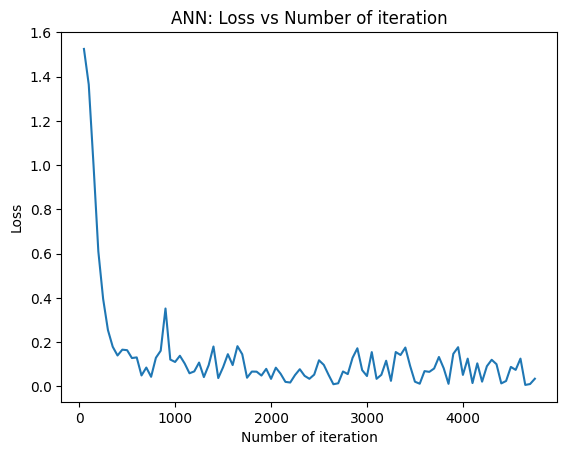

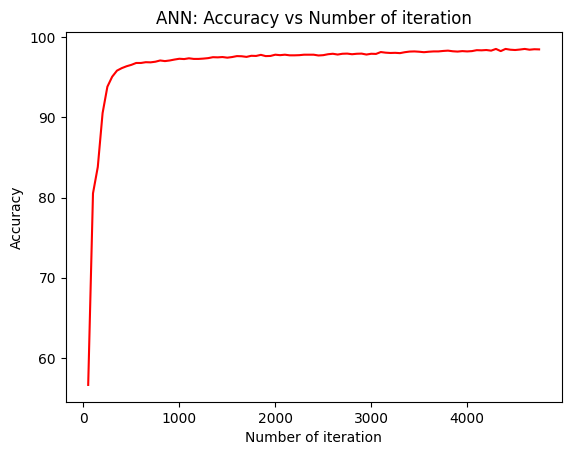

In [14]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("ANN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("ANN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 시각화된 모델의 학습 결과를 해석해주세요.** 🤗



---
**[해석]**
- 학습 초반(0-300 iteration)에 정확도가 약 57%에서 95% 이상으로 급격히 상승했다. 처음에는 가중치가 무작위라 거의 찍는 수준이지만, 몇 백 번의 업데이트만으로 숫자를 구분하는 핵심 패턴을 빠르게 학습했음을 의미한다. 같은 구간에서 loss는 급격히 감소했다.
- 약 500 iteration 이후로는 정확도가 97-98% 부근에서 완만하게 상승하며 수렴했고, loss 역시 낮은 값에서 안정화되었다. 즉 학습이 잘 이루어졌으며, 이후 추가 iteration은 성능 향상 폭이 작다.
- 정확도 곡선이 크게 흔들리지 않고 매끄럽게 올라간 것으로 보아, learning rate 0.02는 발산하거나 진동하지 않는 적절한 값이었다. 0-4 다섯 개 클래스만 사용해 문제가 비교적 쉽고, 3개의 hidden layer와 비선형 활성화 함수(ReLU, Tanh, ELU)가 단순 로지스틱 회귀보다 복잡한 결정 경계를 만들 수 있었기 때문이다.
- 학습 정확도와 테스트 정확도가 함께 높게 유지되므로 이 설정에서는 과적합 징후는 뚜렷하지 않다. 남은 약 2%의 오차는 획이 비슷한 숫자(예: 3과 2, 4와 1 등)에서 주로 발생했을 것으로 추정된다.


#### **ANN 최적의 하이퍼파라미터 찾기**

1️⃣ **실험 1: Hidden Dimension 최적값 찾기**
- hidden_dim 값을 50-200 사이 값들로 설정하고 모델을 학습
- 각 hidden_dim 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교




2️⃣ **실험 2: Learning Rate 최적값 찾기**

- learning_rate 값을 0.1-0.005 사이 값들로 설정하고 모델을 학습
- 각 learning_rate 값에 대해 학습을 수행하면서 loss과 accuracy를 저장
- 모든 결과를 한 그래프에 표시하여 비교



**⚠ 이때 epoch 값은 자유롭게 해주셔도 됩니다! **

In [15]:
# 실험 1 hidden_dims=[50-200 사이 값들] 로 학습
def train_ann(hidden_dim, learning_rate, num_epochs=5, eval_every=50):
    torch.manual_seed(42)
    model = ANNModel(28 * 28, hidden_dim, 5)

    loss_ftn = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    count = 0
    it_list, loss_hist, acc_hist = [], [], []

    for epoch in range(num_epochs):
        for images, labels in train_loader:
            train = images.view(-1, 28 * 28)
            optimizer.zero_grad()
            outputs = model(train)
            loss = loss_ftn(outputs, labels)
            loss.backward()
            optimizer.step()
            count += 1

            if count % eval_every == 0:
                correct, total = 0, 0
                with torch.no_grad():
                    for images, labels in test_loader:
                        outputs = model(images.view(-1, 28 * 28))
                        predicted = torch.max(outputs.data, 1)[1]
                        total += len(labels)
                        correct += (predicted == labels).sum().item()
                it_list.append(count)
                loss_hist.append(loss.item())
                acc_hist.append(100 * correct / total)

    print(f"hidden_dim={hidden_dim}, lr={learning_rate} -> 최종 accuracy: {acc_hist[-1]:.2f} %")
    return it_list, loss_hist, acc_hist


hidden_dims = [50, 100, 150, 200]
exp1_results = {}
for hd in hidden_dims:
    exp1_results[hd] = train_ann(hidden_dim=hd, learning_rate=0.02, num_epochs=5)

hidden_dim=50, lr=0.02 -> 최종 accuracy: 97.82 %
hidden_dim=100, lr=0.02 -> 최종 accuracy: 97.66 %
hidden_dim=150, lr=0.02 -> 최종 accuracy: 97.88 %
hidden_dim=200, lr=0.02 -> 최종 accuracy: 97.86 %


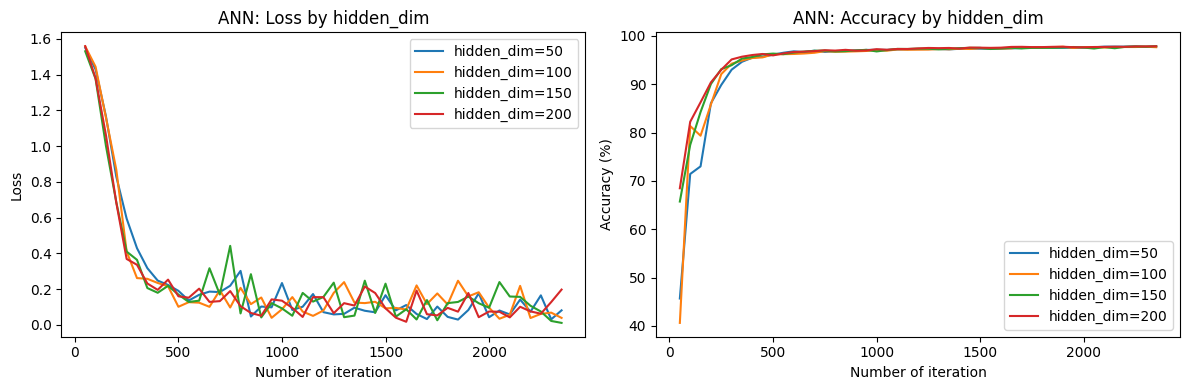

In [16]:
# 실험 1 모델 학습 결과 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for hd, (its, losses, accs) in exp1_results.items():
    plt.plot(its, losses, label=f"hidden_dim={hd}")
plt.xlabel("Number of iteration"); plt.ylabel("Loss")
plt.title("ANN: Loss by hidden_dim"); plt.legend()

plt.subplot(1, 2, 2)
for hd, (its, losses, accs) in exp1_results.items():
    plt.plot(its, accs, label=f"hidden_dim={hd}")
plt.xlabel("Number of iteration"); plt.ylabel("Accuracy (%)")
plt.title("ANN: Accuracy by hidden_dim"); plt.legend()

plt.tight_layout(); plt.show()

**해당 셀의 마크 다운을 풀고 hidden dimension 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**

- 학습 초반(0-300 iteration)에는 hidden_dim에 따른 차이가 뚜렷했다. hidden_dim=50은 100 iteration 시점 정확도가 약 70%로 가장 낮았고 loss 감소도 가장 완만했던 반면, hidden_dim=200은 같은 시점에 약 80% 이상으로 가장 빠르게 상승했다. 뉴런 수가 많을수록 한 번의 업데이트로 조정되는 파라미터가 많아 입력의 다양한 특징을 동시에 포착할 수 있기 때문이다(표현력 증가 → 빠른 수렴).
- 그러나 약 500 iteration 이후에는 네 곡선이 거의 겹쳐 최종 정확도가 모두 97-98% 수준으로 수렴했다. MNIST 0-4 분류는 비교적 단순한 문제라 50개 뉴런만으로도 충분한 표현력을 갖기 때문이며, 그 이상 늘려도 성능 향상은 미미하다(수확 체감).
- 수렴 이후 loss는 모든 hidden_dim에서 0-0.3 사이를 오르내렸는데, 이는 mini-batch 단위로 loss를 기록하기 때문에 생기는 노이즈로 hidden_dim과는 큰 관련이 없다. 다만 hidden_dim=200이 전반적으로 가장 낮은 loss 값을 유지했다.
- hidden_dim이 커지면 파라미터 수가 늘어 학습 시간과 메모리가 증가하고, 데이터가 적거나 복잡한 문제에서는 과적합 위험이 커진다. 반대로 너무 작으면 underfitting으로 성능 상한이 낮아지고 수렴도 느려진다.
- 따라서 hidden_dim은 "클수록 좋다"가 아니라 성능이 포화되는 최소 크기 근처를 고르는 것이 효율적이다. 이 실험에서는 100-150 정도가 수렴 속도와 비용의 균형점으로 보이며, 초반 수렴 속도까지 고려하면 200도 무리 없는 선택이다.

In [17]:
# 실험 2 learning_rates=[0.1-0.005 사이 값들] 로 학습
learning_rates = [0.1, 0.05, 0.02, 0.01, 0.005]
exp2_results = {}
for lr in learning_rates:
    exp2_results[lr] = train_ann(hidden_dim=150, learning_rate=lr, num_epochs=5)

hidden_dim=150, lr=0.1 -> 최종 accuracy: 99.22 %
hidden_dim=150, lr=0.05 -> 최종 accuracy: 98.56 %
hidden_dim=150, lr=0.02 -> 최종 accuracy: 97.88 %
hidden_dim=150, lr=0.01 -> 최종 accuracy: 97.33 %
hidden_dim=150, lr=0.005 -> 최종 accuracy: 96.65 %


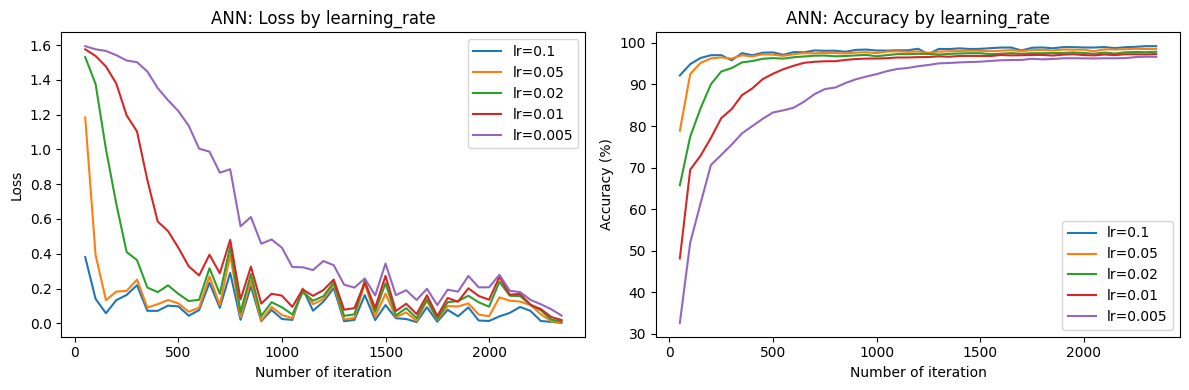

In [18]:
# 실험 2 모델 학습 결과 시각화
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for lr, (its, losses, accs) in exp2_results.items():
    plt.plot(its, losses, label=f"lr={lr}")
plt.xlabel("Number of iteration"); plt.ylabel("Loss")
plt.title("ANN: Loss by learning_rate"); plt.legend()

plt.subplot(1, 2, 2)
for lr, (its, losses, accs) in exp2_results.items():
    plt.plot(its, accs, label=f"lr={lr}")
plt.xlabel("Number of iteration"); plt.ylabel("Accuracy (%)")
plt.title("ANN: Accuracy by learning_rate"); plt.legend()

plt.tight_layout(); plt.show()

**해당 셀의 마크 다운을 풀고 learning rate 값이 모델의 학습에 주는 영향을 설명해주세요.** 🤗



---
**[답변]**

- learning rate이 클수록 loss 감소와 accuracy 상승이 뚜렷하게 빨랐다. 50 iteration 시점 정확도가 lr=0.1은 약 92%, 0.05는 79%, 0.02는 66%, 0.01은 48%, 0.005는 33%로 lr 순서 그대로 층을 이루었다. learning rate는 한 번의 업데이트에서 가중치를 이동시키는 보폭이므로, 클수록 같은 iteration 수에서 더 멀리 이동해 최적점에 빨리 도달하기 때문이다.
- lr=0.005는 수렴이 매우 느려 500 iteration에서도 loss가 0.6 수준이었고, 2000 iteration을 넘어서야 다른 설정을 따라잡았다. 보폭이 너무 작으면 같은 성능에 도달하기 위해 훨씬 많은 iteration(=시간)이 필요하다는 것을 보여준다.
- 일반적으로 lr이 너무 크면 최적점을 지나쳐 loss가 진동하거나 발산하지만, 이 실험의 lr=0.1은 발산하지 않고 오히려 가장 낮은 loss를 유지했다. MNIST 0-4 분류의 손실 지형이 비교적 완만해 0.1도 아직 안전한 범위 안에 있었기 때문으로 예상된다. 다만 수렴 이후 loss가 모든 lr에서 0-0.4 사이를 오르내리는 것은 mini-batch 노이즈이며, lr이 클수록 이 요동의 폭이 커지는 경향이 있다.
- 최종 정확도는 대부분 97-98%로 수렴했으나 lr=0.005만 약간 낮았는데, 이는 성능 한계가 아니라 5 epoch 안에 충분히 수렴하지 못한 결과이다. epoch을 늘리면 결국 비슷한 수준에 도달할 것이다.
- 즉, learning rate는 최종 성능보다 "얼마나 빨리, 얼마나 안정적으로 수렴하느냐"를 결정하는 hyperparameter이다. 너무 작으면 학습이 느리고, 너무 크면 발산 위험이 있으므로, 발산하지 않는 범위에서 가장 큰 값을 고르는 것이 효율적이다. 이 실험에서는 0.05-0.1이 최적이었다.

<a id="1"></a> <br>
## **2. CNN**
> CNN은 이미지 분류에 적합한 모델로, kernel을 이용해 feature map을 생성합니다

**↪ 2개의 합성곱 계층을 쌓고, 활성화 함수로 ReLU를 사용하며,Max Pooling layer를 적용해봅시다.**

#### **CNN 모델 생성**

In [19]:
import torch
import torch.nn as nn
import torch.optim as optim

# CNN Model 정의
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()

        # 합성곱 계층 1 (Conv Layer 1)
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()  # 활성화 함수 (ReLU)
        # Max Pooling 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)  # kernel size를 2로 설정

        # 합성곱 계층 2 (Conv Layer 2)
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()  # 활성화 함수 (ReLU)

        # Max Pooling 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2) # kernel size를 2로 설정

        # Fully Connected Layer
        self.fc1 = nn.Linear(32 * 4 * 4, 5)  # 입력 차원 및 출력 차원 지정

    def forward(self, x):
        # 합성곱 계층 1 + 활성화 함수
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max Pooling 1
        out = self.maxpool1(out)

        # 합성곱 계층 2 + 활성화 함수
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max Pooling 2
        out = self.maxpool2(out)

        # feature map을 flatten하게
        out = out.view(out.size(0), -1)

        # 완전 연결 계층
        out = self.fc1(out)

        return out


In [20]:
# CNN 객체 생성
model = CNNModel()
# 손실 함수 설정
loss_ftn = nn.CrossEntropyLoss()  # 다중분류에 적합한 손실함수를 선택해주세요

# SGD Optimizer 사용 - 다른 옵티마이저를 사용해보셔도 됩니다 :)
optimizer = optim.SGD(model.parameters(), lr=0.02)  # 학습률을 자유롭게 설정해주세요

#### **CNN 모델 학습**

In [23]:
# CNN 모델 학습

# 학습을 모니터링하기 위한 변수들
count = 0  # 반복 횟수
loss_list = []  # Loss 저장 리스트
iteration_list = []  # Iteration 저장 리스트
accuracy_list = []  # 정확도 저장 리스트
num_epochs = 20  # 학습할 에포크 수 설정 -> 자유롭게 설정해주셔도 됩니다

for epoch in range(num_epochs):
    running_loss = 0.0  # 에포크별 손실 초기화

    for images, labels in train_loader:
        # 옵티마이저의 기울기 초기화
        optimizer.zero_grad()

        # Forward
        outputs = model(images)

        # 손실 계산
        loss = loss_ftn(outputs, labels)

        # Backward
        loss.backward()

        # 가중치 업데이트
        optimizer.step()

        # 손실 누적
        running_loss += loss.item()
        count += 1  # 반복 횟수 증가

        if count % 50 == 0:
            correct = 0
            total = 0

            with torch.no_grad():  # 평가
                for images, labels in test_loader:
                    # 모델 예측 수행
                    outputs = model(images)

                    # 가장 확률이 높은 클래스 선택
                    predicted = torch.max(outputs.data, 1)[1]

                    # 총 샘플 수 및 올바른 예측 개수 누적
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()

            # 정확도 계산
            accuracy = 100 * correct / float(total)

            # 손실 및 정확도 저장
            loss_list.append(loss.item())
            iteration_list.append(count)
            accuracy_list.append(accuracy)

    # 매 에포크마다 평균 손실 출력
    print(f"Epoch {epoch+1}, Loss: {running_loss / len(train_loader)}")

Epoch 1, Loss: 0.1404672650180928
Epoch 2, Loss: 0.08870628215314233
Epoch 3, Loss: 0.07057056932210425
Epoch 4, Loss: 0.057430637744692835
Epoch 5, Loss: 0.046057069922519345
Epoch 6, Loss: 0.04043875142371978
Epoch 7, Loss: 0.03558692943313527
Epoch 8, Loss: 0.0327401767130737
Epoch 9, Loss: 0.029917849122307463
Epoch 10, Loss: 0.027896042907365554
Epoch 11, Loss: 0.02596520999134693
Epoch 12, Loss: 0.025208864756957054
Epoch 13, Loss: 0.06211682323389249
Epoch 14, Loss: 0.024445176102942348
Epoch 15, Loss: 0.022338853378552702
Epoch 16, Loss: 0.020652785978065163
Epoch 17, Loss: 0.0197614711079973
Epoch 18, Loss: 0.018828234440528707
Epoch 19, Loss: 0.018037120174881002
Epoch 20, Loss: 0.01708978459497599


#### **CNN 학습 결과**

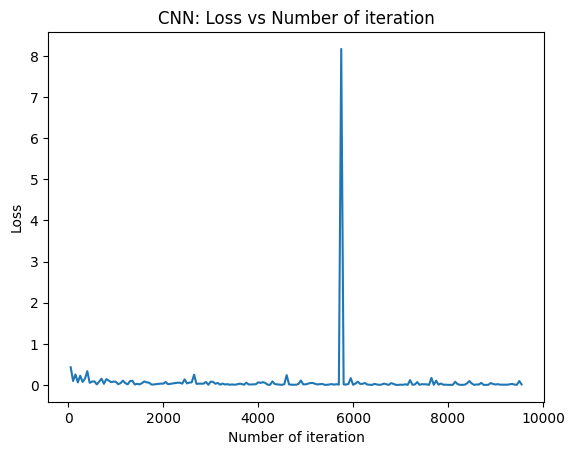

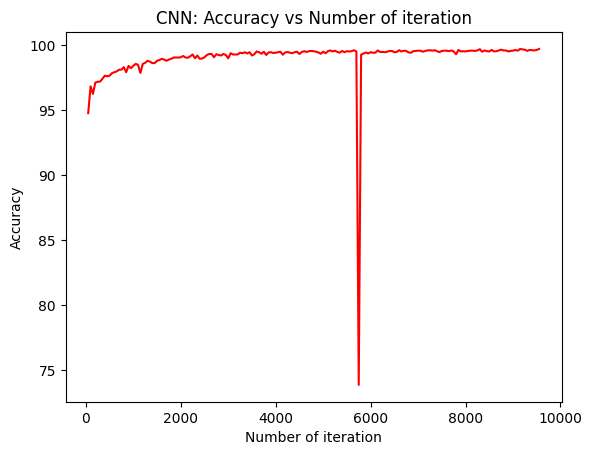

In [24]:
# loss 시각화
plt.plot(iteration_list,loss_list)
plt.xlabel("Number of iteration")
plt.ylabel("Loss")
plt.title("CNN: Loss vs Number of iteration")
plt.show()

# accuracy 시각화
plt.plot(iteration_list,accuracy_list,color = "red")
plt.xlabel("Number of iteration")
plt.ylabel("Accuracy")
plt.title("CNN: Accuracy vs Number of iteration")
plt.show()

**해당 셀의 마크 다운을 풀고 MNIST 데이터셋에서 ANN, CNN의 학습 결과 비교와 함께 두 모델에 대해 각각 짧게 소개해주세요.** 🤗



---
**[답변]**
**3. 학습 결과 비교**

| 항목 | ANN (MLP) | CNN |
|---|---|---|
| 입력 형태 | 784차원 벡터 (펼침) | 1×28×28 이미지 (그대로) |
| 핵심 층 | Linear | Conv2d + MaxPool2d |
| 공간 정보 활용 | ✗ | ✓ |
| 50 iteration 시점 정확도 | 약 57% | 약 95% |
| 최종 테스트 정확도 | 약 98% | 약 99.5% |
| 수렴 속도 | 약 500 iteration 이후 안정 | 약 100 iteration 만에 98% 도달 |
| 수렴 후 loss | 0-0.3 사이 요동 | 0.1 이하에서 안정 |

- 두 모델의 **학습 방식은 완전히 동일**하다 (`zero_grad → forward → loss → backward → step`, CrossEntropyLoss, SGD). 차이는 오직 모델 내부의 층 구성뿐이다.
- CNN은 첫 50 iteration에 이미 95%를 넘겨 ANN(57%)보다 훨씬 빠르게 출발했고, 최종 정확도도 99.5%로 ANN(98%)보다 높았다. 획의 형태와 위치 관계를 필터가 직접 포착하기 때문에 적은 업데이트로도 핵심 패턴을 학습한 것이다.
- 약 5,700 iteration 지점에서 loss가 순간적으로 8까지 치솟고 정확도가 74%로 떨어졌다가 곧바로 복구되는 현상이 관찰되었다. 이는 특정 mini-batch의 기울기가 크게 튀어 SGD가 잠시 최적점을 벗어난 것으로, 바로 다음 배치들에서 99% 이상으로 돌아온 것을 보면 모델이 안정적인 최적점 근처에 잘 수렴해 있었음을 알 수 있다. learning rate를 조금 낮추거나 Adam 같은 적응형 옵티마이저를 쓰면 이런 spike를 줄일 수 있다.
- 다만 MNIST 0-4 분류는 단순한 문제라 ANN도 98%라는 높은 성능을 냈고, CNN은 그보다 1.5%p 정도 앞선 수준이다. 반면 학습 시간은 CNN이 훨씬 오래 걸렸다(ANN 10 epoch 약 1-2분, CNN 20 epoch 약 10분). 즉 이 실험만 놓고 보면 성능 대비 비용 면에서 두 모델의 격차는 크지 않다.
- 이 차이는 문제가 복잡해질수록(클래스 10개, 컬러 이미지, 배경이 있는 실제 사진 등) 훨씬 커진다. ANN은 픽셀 간 관계를 통계적으로 알아내야 하는 반면, CNN은 구조 자체가 이미지의 지역성(locality)을 가정하고 있어 이미지 데이터에 본질적으로 유리하다.
